In [7]:
# ============================================================
# Mechanism Diagnostic: Minibatch Starvation
# Notebooks 1 + 2 + 3 combined
#
# PART 1 (~5 min)  — Synthetic diagnostic
#   Zero-fill vs proper-masking at operating point + R-sweep.
#   Logs q_min(t), presence indicator, loss estimate every step.
#   Produces: mechanism_figure.png, trajectories.csv
#
# PART 2 (~20 min) — CelebA ResNet-50 embedding extraction
#   ResNet-50 (pretrained, frozen, eval), full CelebA train+test.
#   Groups: g = Blond_Hair*2 + Male (g=3 = blonde-male, minority).
#   Saves: celeba_embeddings_train.pt, celeba_embeddings_test.pt
#          celeba_groups_train.pt, celeba_groups_test.pt
#
# PART 3 (~30 min) — CelebA kill-test on real embeddings
#   Linear probe trained with zero-fill DRO vs proper-masking.
#   Same 4-panel figure as Part 1 but on real data.
#   Produces: celeba_mechanism_figure.png, celeba_collapse_results.csv
#
# TOTAL RUNTIME: ~55 min on T4
# DATASET: jessicali9530/celeba-dataset
# ============================================================

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import models, transforms
import numpy as np, pandas as pd, os, json, math, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from scipy import stats
warnings.filterwarnings('ignore')

# ── Shared constants ───────────────────────────────────────────
SEEDS        = [42, 0, 1]
ETA          = 0.1
THR          = 0.01
Q0           = 0.25
DELTA        = math.log(Q0/THR)   # 3.22
N_GROUPS_SYN = 4
BATCH_SYN    = 64
MAX_STEPS    = 2000
DIM          = 64

# CelebA constants
BATCH_EMBED  = 256   # for embedding extraction (large, no grad)
BATCH_PROBE  = 64    # for linear probe DRO
N_GROUPS_CEL = 4     # g = Blond*2 + Male
CELEBA_ROOT  = '/kaggle/input/datasets/jessicali9530/celeba-dataset'
IMG_DIR      = os.path.join(CELEBA_ROOT,'img_align_celeba','img_align_celeba')
ATTR_PATH    = os.path.join(CELEBA_ROOT,'list_attr_celeba.csv')
SPLIT_PATH   = os.path.join(CELEBA_ROOT,'list_eval_partition.csv')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Delta = {DELTA:.4f}')
print('Parts: 1=Synthetic  2=CelebA embedding  3=CelebA kill-test')

Device: cuda
GPU: Tesla T4
Delta = 3.2189
Parts: 1=Synthetic  2=CelebA embedding  3=CelebA kill-test


In [8]:
# ═══════════════════════════════════════════════════════════════
# PART 1: SYNTHETIC DIAGNOSTIC
# ═══════════════════════════════════════════════════════════════
print('='*62)
print('PART 1: Synthetic diagnostic')
print('='*62)

import torch.nn.functional as F

# ── Generator (same as original experiments) ──────────────────
def generate_groups(N_maj, N_min, p_min=0.10, sep=2.0, dim=DIM, seed=42):
    rng = np.random.RandomState(seed)
    def grp(n, gid, off, pc):
        n=int(n); npos=max(1,int(n*pc)); nneg=n-npos
        Xp=rng.randn(npos,dim); Xp[:,0]+=sep/2; Xp[:,1]+=off
        Xn=rng.randn(nneg,dim); Xn[:,0]-=sep/2; Xn[:,1]+=off
        X=np.vstack([Xp,Xn]).astype(np.float32)
        y=np.array([1]*npos+[0]*nneg,dtype=np.int64)
        g=np.array([gid*2+yi for yi in y],dtype=np.int64)
        return X,y,g
    XA,yA,gA=grp(N_maj,0,+1.0,0.50)
    XB,yB,gB=grp(N_min,1,-1.0,p_min)
    return (np.vstack([XA,XB]),np.concatenate([yA,yB]),
            np.concatenate([gA,gB]))

class LinCls(nn.Module):
    def __init__(self,d=DIM): super().__init__(); self.fc=nn.Linear(d,2)
    def forward(self,x): return self.fc(x)

# ── DRO runner with full per-step logging ─────────────────────
def run_dro_logged(X,y,g,convention,n_groups=N_GROUPS_SYN,
                   eta=ETA,B=BATCH_SYN,max_steps=MAX_STEPS,seed=42):
    """
    Returns dict with:
      q_min_trace   : [max_steps] q_min at each step
      presence_trace: [max_steps] whether g3 was present
      lhat_trace    : [max_steps] lhat[g3] (0 if absent under zerofill)
      collapse_step : int or None
    convention: 'zerofill' | 'masked_proper'
    """
    torch.manual_seed(seed); np.random.seed(seed)
    ds=TensorDataset(torch.from_numpy(X).float(),
                     torch.from_numpy(y).long(),
                     torch.from_numpy(g).long())
    ld=DataLoader(ds,batch_size=B,shuffle=True)
    model=LinCls(X.shape[1]).to(device)
    opt=optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
    q=torch.ones(n_groups).to(device)/n_groups
    collapse_step=None
    step=0
    q_min_trace=[]; presence_trace=[]; lhat_trace=[]

    while step<max_steps:
        for xb,yb,gb in ld:
            if step>=max_steps: break
            xb,yb,gb=xb.to(device),yb.to(device),gb.to(device)
            opt.zero_grad()
            losses=nn.CrossEntropyLoss(reduction='none')(model(xb),yb)
            g_loss=torch.zeros(n_groups).to(device)
            present=[]
            for gi in range(n_groups):
                m=gb==gi
                if m.sum()>0:
                    g_loss[gi]=losses[m].mean()
                    present.append(gi)
            g3_present = (3 in present)
            g3_lhat = float(g_loss[3].item())

            if convention=='zerofill':
                q=q*torch.exp(eta*g_loss.detach()); q=q/q.sum()
            elif convention=='masked_proper':
                if present:
                    pres=torch.tensor(present,device=device)
                    mass_before=q[pres].sum()
                    qn=q.clone()
                    qn[pres]=q[pres]*torch.exp(eta*g_loss[pres].detach())
                    qn[pres]=qn[pres]*mass_before/qn[pres].sum()
                    q=qn

            (q*g_loss).sum().backward(); opt.step(); step+=1
            mq=float(q.min().item())
            q_min_trace.append(mq)
            presence_trace.append(int(g3_present))
            lhat_trace.append(g3_lhat if g3_present else 0.0)
            if collapse_step is None and mq<THR:
                collapse_step=step

    return {'q_min_trace':q_min_trace,'presence_trace':presence_trace,
            'lhat_trace':lhat_trace,'collapse_step':collapse_step}

# ── Run at operating point: R=10, 3 seeds ─────────────────────
N_MAJ_OP, N_MIN_OP = 2000, 200
print(f'Operating point: N_maj={N_MAJ_OP}, N_min={N_MIN_OP}, R=10, p=0.10')

results_op = {}
for conv in ['zerofill','masked_proper']:
    print(f'  Running {conv}...')
    traces=[]
    for seed in SEEDS:
        X,y,g=generate_groups(N_MAJ_OP,N_MIN_OP,seed=seed)
        r=run_dro_logged(X,y,g,conv,seed=seed)
        traces.append(r)
        cs=r['collapse_step']
        print(f'    seed {seed}: collapse_step={cs}')
    results_op[conv]=traces

# ── R-sweep for trajectory shape ─────────────────────────────
R_VALS_PLOT=[5,10,20,50]
print('\nR-sweep (zerofill, seed=42)...')
results_Rsweep={}
for R in R_VALS_PLOT:
    N_min=max(1,int(N_MAJ_OP/R))
    X,y,g=generate_groups(N_MAJ_OP,N_min,seed=42)
    r=run_dro_logged(X,y,g,'zerofill',seed=42,max_steps=MAX_STEPS)
    results_Rsweep[R]=r
    print(f'  R={R:>3}: collapse_step={r["collapse_step"]}')

print('\nPart 1 runs done.')

PART 1: Synthetic diagnostic
Operating point: N_maj=2000, N_min=200, R=10, p=0.10
  Running zerofill...
    seed 42: collapse_step=81
    seed 0: collapse_step=119
    seed 1: collapse_step=77
  Running masked_proper...
    seed 42: collapse_step=None
    seed 0: collapse_step=1391
    seed 1: collapse_step=None

R-sweep (zerofill, seed=42)...
  R=  5: collapse_step=149
  R= 10: collapse_step=81
  R= 20: collapse_step=63
  R= 50: collapse_step=58

Part 1 runs done.


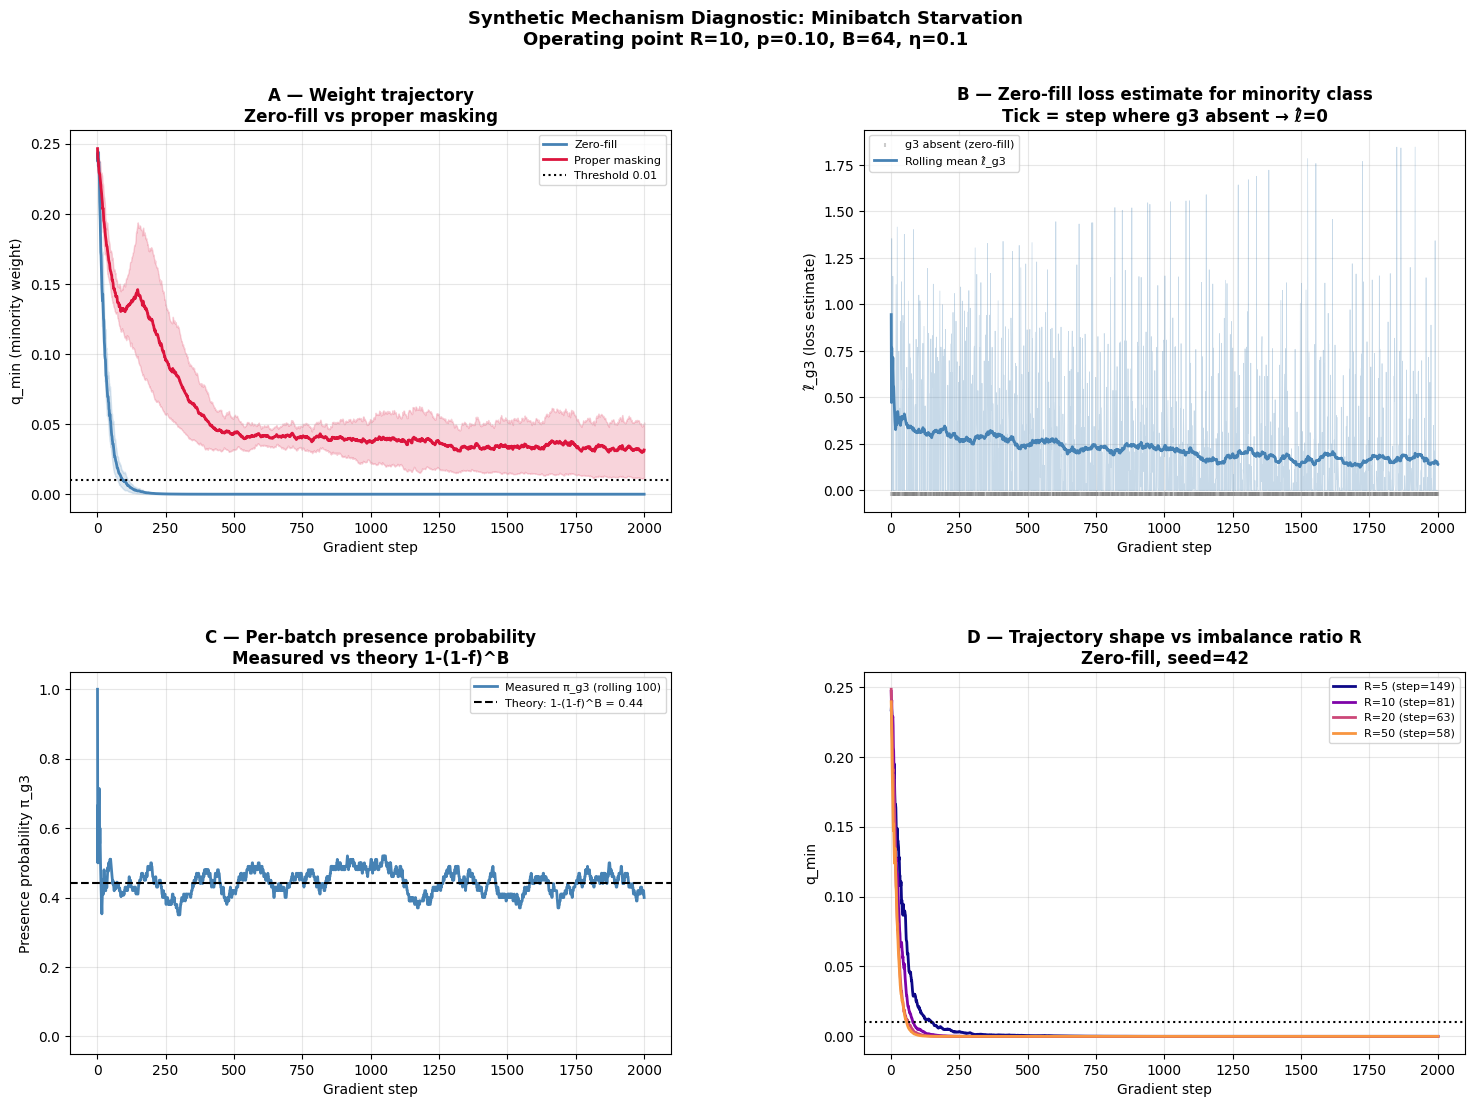

Saved: mechanism_figure.png
Saved: trajectories.csv

--- Part 1 summary ---
  zerofill: collapse steps = ['81', '119', '77']
  masked_proper: collapse steps = ['>2000', '1391', '>2000']


In [9]:
# ── Part 1 figure: 4-panel mechanism diagnostic ───────────────
def rolling_mean(arr,w=50):
    out=np.full(len(arr),np.nan)
    for i in range(len(arr)):
        out[i]=np.mean(arr[max(0,i-w+1):i+1])
    return out

fig=plt.figure(figsize=(18,12))
fig.suptitle('Synthetic Mechanism Diagnostic: Minibatch Starvation\n'
             'Operating point R=10, p=0.10, B=64, η=0.1',
             fontweight='bold',fontsize=13)
gs=gridspec.GridSpec(2,2,figure=fig,hspace=0.42,wspace=0.32)

# Panel A: q_min trajectory — zerofill vs masking (mean±std over seeds)
ax=fig.add_subplot(gs[0,0])
steps=np.arange(1,MAX_STEPS+1)
for conv,color,lab in [('zerofill','steelblue','Zero-fill'),
                        ('masked_proper','crimson','Proper masking')]:
    mat=np.array([r['q_min_trace'] for r in results_op[conv]])
    m=mat.mean(0); s=mat.std(0)
    ax.plot(steps,m,color=color,lw=2,label=lab)
    ax.fill_between(steps,m-s,m+s,color=color,alpha=0.18)
ax.axhline(THR,color='black',ls=':',lw=1.5,label=f'Threshold {THR}')
ax.set_xlabel('Gradient step'); ax.set_ylabel('q_min (minority weight)')
ax.set_title('A — Weight trajectory\nZero-fill vs proper masking',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

# Panel B: Loss estimate for g3 — zero-fill only, with absence markers
ax=fig.add_subplot(gs[0,1])
r0=results_op['zerofill'][0]   # seed 42
lhat=np.array(r0['lhat_trace'])
pres=np.array(r0['presence_trace'])
roll=rolling_mean(lhat,w=100)
abs_steps=steps[pres==0]
ax.scatter(abs_steps,np.zeros(len(abs_steps))-0.02,
           marker='|',color='gray',s=8,alpha=0.4,label='g3 absent (zero-fill)')
ax.plot(steps,roll,color='steelblue',lw=2,label='Rolling mean ℓ̂_g3')
ax.plot(steps,lhat,color='steelblue',lw=0.5,alpha=0.3)
ax.set_xlabel('Gradient step'); ax.set_ylabel('ℓ̂_g3 (loss estimate)')
ax.set_title('B — Zero-fill loss estimate for minority class\n'
             'Tick = step where g3 absent → ℓ̂=0',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

# Panel C: Rolling presence probability π_g3
ax=fig.add_subplot(gs[1,0])
pi_roll=rolling_mean(pres,w=100)
f_theory=0.10/11   # p/(1+R)
pi_theory=1-(1-f_theory)**BATCH_SYN
ax.plot(steps,pi_roll,color='steelblue',lw=2,label='Measured π_g3 (rolling 100)')
ax.axhline(pi_theory,color='black',ls='--',lw=1.5,
           label=f'Theory: 1-(1-f)^B = {pi_theory:.2f}')
ax.set_xlabel('Gradient step'); ax.set_ylabel('Presence probability π_g3')
ax.set_title('C — Per-batch presence probability\nMeasured vs theory 1-(1-f)^B',
             fontweight='bold')
ax.set_ylim(-0.05,1.05); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

# Panel D: R-sweep trajectory comparison
ax=fig.add_subplot(gs[1,1])
cmap=plt.cm.plasma
R_arr=np.array(R_VALS_PLOT)
for i,R in enumerate(R_VALS_PLOT):
    r=results_Rsweep[R]
    qtr=np.array(r['q_min_trace'])
    color=cmap(i/len(R_VALS_PLOT))
    ax.plot(steps,qtr,color=color,lw=2,
            label=f'R={R} (step={r["collapse_step"]})')
ax.axhline(THR,color='black',ls=':',lw=1.5)
ax.set_xlabel('Gradient step'); ax.set_ylabel('q_min')
ax.set_title('D — Trajectory shape vs imbalance ratio R\n'
             'Zero-fill, seed=42',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

fig.savefig('mechanism_figure.png',dpi=300,bbox_inches='tight')
plt.show()
print('Saved: mechanism_figure.png')

# ── Save trajectories CSV ─────────────────────────────────────
rows=[]
for conv in ['zerofill','masked_proper']:
    for si,seed in enumerate(SEEDS):
        r=results_op[conv][si]
        for step_i,(qm,pr,lh) in enumerate(
                zip(r['q_min_trace'],r['presence_trace'],r['lhat_trace'])):
            rows.append({'convention':conv,'seed':seed,'step':step_i+1,
                         'q_min':round(qm,6),'g3_present':pr,
                         'g3_lhat':round(lh,6)})
pd.DataFrame(rows).to_csv('trajectories.csv',index=False)
print('Saved: trajectories.csv')

# Summary
print('\n--- Part 1 summary ---')
for conv in ['zerofill','masked_proper']:
    css=[r['collapse_step'] for r in results_op[conv]]
    css_str=[str(s) if s else '>2000' for s in css]
    print(f'  {conv}: collapse steps = {css_str}')

In [10]:
# ═══════════════════════════════════════════════════════════════
# PART 2: CelebA EMBEDDING EXTRACTION
# ResNet-50 pretrained, eval mode, no grad.
# Groups: g = Blond_Hair*2 + Male
#   g=0: dark-hair female   g=1: dark-hair male
#   g=2: blonde female      g=3: blonde male  <- minority class
# ═══════════════════════════════════════════════════════════════
print('='*62)
print('PART 2: CelebA ResNet-50 embedding extraction')
print('='*62)

class CelebADataset(Dataset):
    def __init__(self,img_dir,attr_path,split_path,split='train',transform=None):
        attrs=pd.read_csv(attr_path); attrs.columns=attrs.columns.str.strip()
        attrs=attrs.set_index(attrs.columns[0])
        splits=pd.read_csv(split_path); splits.columns=splits.columns.str.strip()
        splits=splits.set_index(splits.columns[0])
        part_col=splits.columns[0]
        split_map={'train':0,'val':1,'test':2}
        files=splits[splits[part_col]==split_map[split]].index
        self.img_dir=img_dir; self.transform=transform; self.records=[]
        for fname in files:
            if fname not in attrs.index: continue
            row=attrs.loc[fname]
            y=int(row['Blond_Hair']==1); a=int(row['Male']==1)
            self.records.append((fname,y,y*2+a))
        self.records=self.records  # all split
        print(f'  Split={split}: {len(self.records):,} images')
    def __len__(self): return len(self.records)
    def __getitem__(self,idx):
        fname,y,group=self.records[idx]
        img=Image.open(os.path.join(self.img_dir,fname)).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,y,group

EMBED_TF=transforms.Compose([
    transforms.Resize(256),transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

# Load ResNet-50, remove FC
print('Loading ResNet-50...')
resnet=models.resnet50(pretrained=True)
embed_dim=resnet.fc.in_features   # 2048
resnet.fc=nn.Identity()
resnet=resnet.to(device).eval()
print(f'Embedding dim: {embed_dim}')

def extract_embeddings(split):
    ds=CelebADataset(IMG_DIR,ATTR_PATH,SPLIT_PATH,split,EMBED_TF)
    ld=DataLoader(ds,batch_size=BATCH_EMBED,shuffle=False,
                  num_workers=2,pin_memory=True)
    embs,ys,gs=[],[],[]
    with torch.no_grad():
        for i,(xb,yb,gb) in enumerate(ld):
            e=resnet(xb.to(device)).cpu()
            embs.append(e); ys.append(yb); gs.append(gb)
            if (i+1)%20==0:
                print(f'    {(i+1)*BATCH_EMBED}/{len(ds)} done')
    return torch.cat(embs),torch.cat(ys),torch.cat(gs)

print('Extracting train embeddings...')
X_tr,y_tr,g_tr=extract_embeddings('train')
print('Extracting test embeddings...')
X_te,y_te,g_te=extract_embeddings('test')

torch.save(X_tr,'celeba_embeddings_train.pt')
torch.save(y_tr,'celeba_labels_train.pt')
torch.save(g_tr,'celeba_groups_train.pt')
torch.save(X_te,'celeba_embeddings_test.pt')
torch.save(y_te,'celeba_labels_test.pt')
torch.save(g_te,'celeba_groups_test.pt')

print(f'\nSaved embeddings: train={X_tr.shape}, test={X_te.shape}')
print('Group counts (train):')
for g in range(4):
    name=['dark-female','dark-male','blonde-female','blonde-male'][g]
    cnt=int((g_tr==g).sum())
    print(f'  g={g} ({name}): {cnt:,}')
g3_cnt=int((g_tr==3).sum()); g2_cnt=int((g_tr==2).sum())
g01_cnt=int(((g_tr==0)|(g_tr==1)).sum())
P_CEL=g3_cnt/(g3_cnt+g2_cnt); R_CEL=g01_cnt/(g3_cnt+g2_cnt)
f_cel=P_CEL/(1+R_CEL)
pi_cel=1-(1-f_cel)**BATCH_PROBE
print(f'\np_natural={P_CEL:.4f}  R_natural={R_CEL:.2f}')
print(f'f={f_cel:.5f}  pi_g3={pi_cel:.3f}  (g3 present {pi_cel*100:.1f}% of batches)')
print(f'Predicted floor: Delta/(eta*lbar) ~ {DELTA/(ETA*0.6):.0f} steps')

PART 2: CelebA ResNet-50 embedding extraction
Loading ResNet-50...
Embedding dim: 2048
Extracting train embeddings...
  Split=train: 162,770 images
    5120/162770 done
    10240/162770 done
    15360/162770 done
    20480/162770 done
    25600/162770 done
    30720/162770 done
    35840/162770 done
    40960/162770 done
    46080/162770 done
    51200/162770 done
    56320/162770 done
    61440/162770 done
    66560/162770 done
    71680/162770 done
    76800/162770 done
    81920/162770 done
    87040/162770 done
    92160/162770 done
    97280/162770 done
    102400/162770 done
    107520/162770 done
    112640/162770 done
    117760/162770 done
    122880/162770 done
    128000/162770 done
    133120/162770 done
    138240/162770 done
    143360/162770 done
    148480/162770 done
    153600/162770 done
    158720/162770 done
Extracting test embeddings...
  Split=test: 19,962 images
    5120/19962 done
    10240/19962 done
    15360/19962 done

Saved embeddings: train=torch.Size([16

In [11]:
# ═══════════════════════════════════════════════════════════════
# PART 3: CelebA KILL-TEST ON REAL EMBEDDINGS
# ═══════════════════════════════════════════════════════════════
print('='*62)
print('PART 3: CelebA kill-test on real ResNet-50 embeddings')
print('='*62)

# Move embeddings to tensors
X_tr_t=X_tr.float(); y_tr_t=y_tr.long(); g_tr_t=g_tr.long()
X_te_t=X_te.float(); y_te_t=y_te.long(); g_te_t=g_te.long()

MAX_STEPS_CEL=3000   # longer budget for real data

def run_dro_celeba_logged(convention, seed=42,
                          eta=ETA,B=BATCH_PROBE,
                          max_steps=MAX_STEPS_CEL):
    torch.manual_seed(seed); np.random.seed(seed)
    ds=TensorDataset(X_tr_t,y_tr_t,g_tr_t)
    ld=DataLoader(ds,batch_size=B,shuffle=True,
                  num_workers=0,pin_memory=False)
    model=LinCls(embed_dim).to(device)
    opt=optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
    q=torch.ones(N_GROUPS_CEL).to(device)/N_GROUPS_CEL
    collapse_step=None; step=0
    q_min_trace=[]; presence_trace=[]; lhat_trace=[]; acc_trace=[]

    # Eval loader (small for speed)
    ds_te=TensorDataset(X_te_t,y_te_t,g_te_t)
    ld_te=DataLoader(ds_te,batch_size=512,shuffle=False)

    while step<max_steps:
        for xb,yb,gb in ld:
            if step>=max_steps: break
            xb,yb,gb=xb.to(device),yb.to(device),gb.to(device)
            opt.zero_grad()
            losses=nn.CrossEntropyLoss(reduction='none')(model(xb),yb)
            g_loss=torch.zeros(N_GROUPS_CEL).to(device); present=[]
            for gi in range(N_GROUPS_CEL):
                m=gb==gi
                if m.sum()>0:
                    g_loss[gi]=losses[m].mean(); present.append(gi)
            g3_present=(3 in present)
            g3_lhat=float(g_loss[3].item())

            if convention=='zerofill':
                q=q*torch.exp(eta*g_loss.detach()); q=q/q.sum()
            elif convention=='masked_proper':
                if present:
                    pres=torch.tensor(present,device=device)
                    mass_before=q[pres].sum()
                    qn=q.clone()
                    qn[pres]=q[pres]*torch.exp(eta*g_loss[pres].detach())
                    qn[pres]=qn[pres]*mass_before/qn[pres].sum()
                    q=qn

            (q*g_loss).sum().backward(); opt.step(); step+=1
            mq=float(q.min().item())
            q_min_trace.append(mq)
            presence_trace.append(int(g3_present))
            lhat_trace.append(g3_lhat if g3_present else 0.0)
            if collapse_step is None and mq<THR:
                collapse_step=step

            # Evaluate g3 accuracy every 200 steps
            if step%200==0:
                model.eval()
                g3_correct=0; g3_total=0
                with torch.no_grad():
                    for xte,yte,gte in ld_te:
                        xte,yte,gte=xte.to(device),yte.to(device),gte.to(device)
                        pred=model(xte).argmax(1)
                        m3=gte==3
                        if m3.sum()>0:
                            g3_correct+=int((pred[m3]==yte[m3]).sum())
                            g3_total+=int(m3.sum())
                g3_acc=g3_correct/g3_total if g3_total>0 else float('nan')
                acc_trace.append((step,g3_acc))
                model.train()

    return {'q_min_trace':q_min_trace,'presence_trace':presence_trace,
            'lhat_trace':lhat_trace,'collapse_step':collapse_step,
            'acc_trace':acc_trace}

results_cel={}
for conv in ['zerofill','masked_proper']:
    print(f'\n--- CelebA {conv} ---')
    traces=[]
    for seed in SEEDS:
        print(f'  seed {seed}...',end=' ',flush=True)
        r=run_dro_celeba_logged(conv,seed=seed)
        traces.append(r)
        cs=r['collapse_step']
        print(f'collapse_step={cs}')
    results_cel[conv]=traces

print('\nPart 3 runs done.')

PART 3: CelebA kill-test on real ResNet-50 embeddings

--- CelebA zerofill ---
  seed 42... collapse_step=419
  seed 0... collapse_step=430
  seed 1... collapse_step=690

--- CelebA masked_proper ---
  seed 42... collapse_step=1126
  seed 0... collapse_step=623
  seed 1... collapse_step=523

Part 3 runs done.


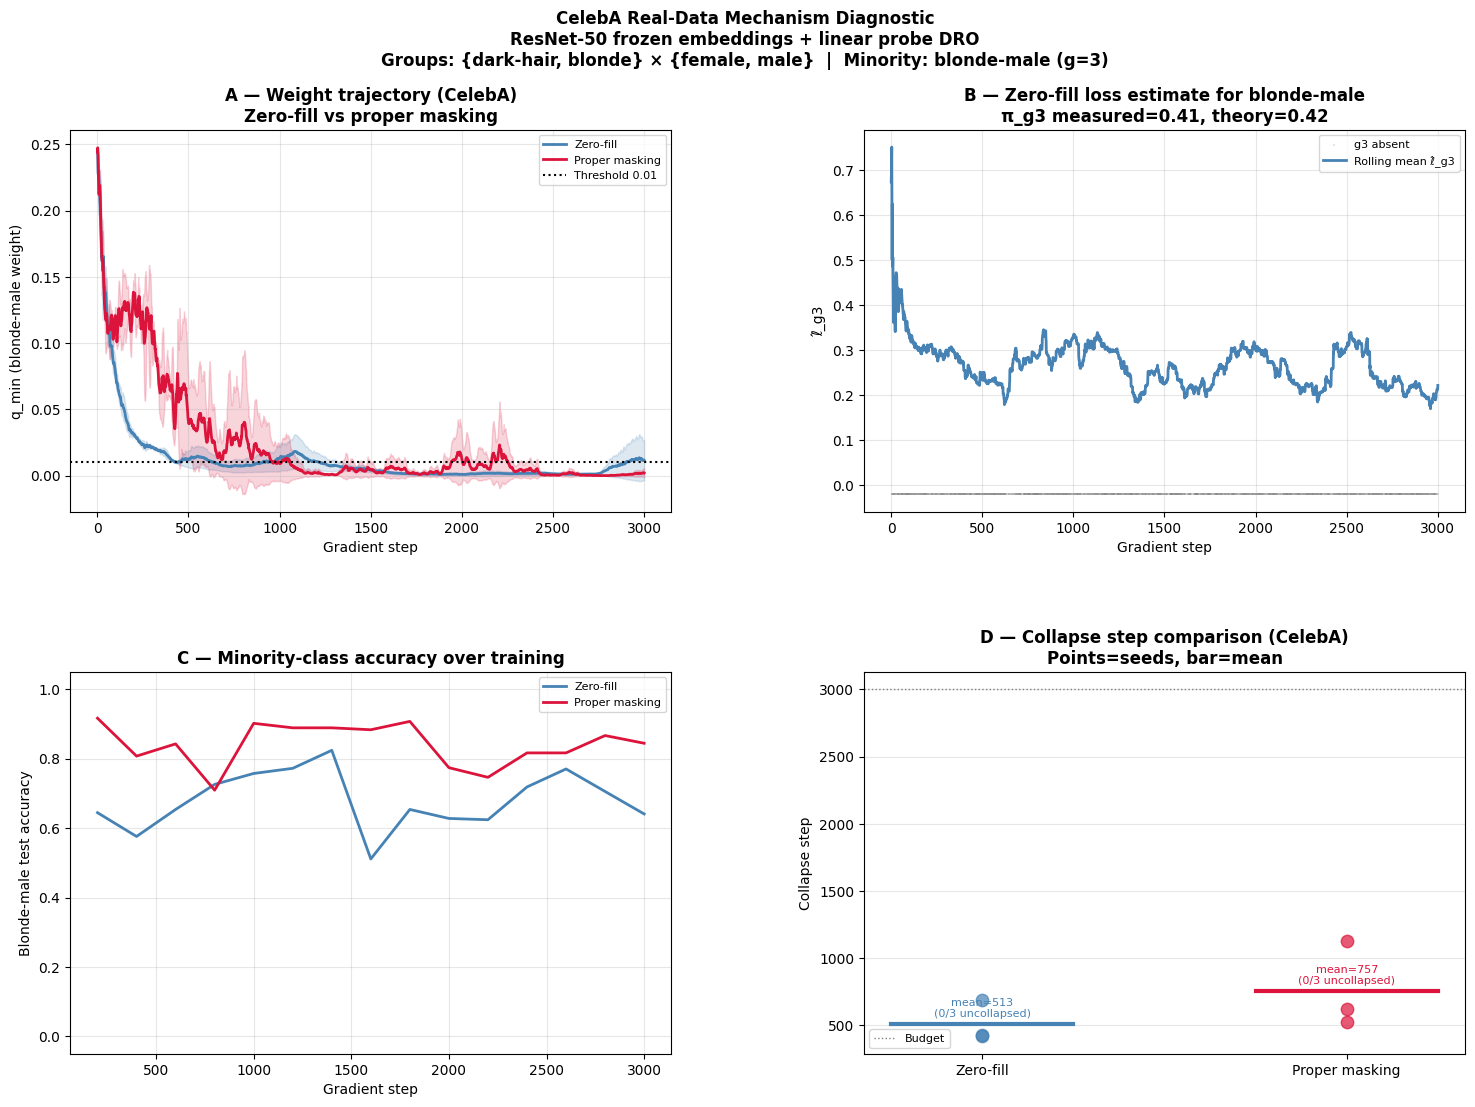

Saved: celeba_mechanism_figure.png
Saved: celeba_collapse_results.csv


In [12]:
# ── Part 3 figure: CelebA 4-panel ─────────────────────────────
steps_cel=np.arange(1,MAX_STEPS_CEL+1)

fig2=plt.figure(figsize=(18,12))
fig2.suptitle('CelebA Real-Data Mechanism Diagnostic\n'
              'ResNet-50 frozen embeddings + linear probe DRO\n'
              'Groups: {dark-hair, blonde} × {female, male}  |  '
              'Minority: blonde-male (g=3)',
              fontweight='bold',fontsize=12)
gs2=gridspec.GridSpec(2,2,figure=fig2,hspace=0.42,wspace=0.32)

# Panel A: q_min trajectory
ax=fig2.add_subplot(gs2[0,0])
for conv,color,lab in [('zerofill','steelblue','Zero-fill'),
                        ('masked_proper','crimson','Proper masking')]:
    mat=np.array([r['q_min_trace'] for r in results_cel[conv]])
    m=mat.mean(0); s=mat.std(0)
    ax.plot(steps_cel,m,color=color,lw=2,label=lab)
    ax.fill_between(steps_cel,m-s,m+s,color=color,alpha=0.18)
ax.axhline(THR,color='black',ls=':',lw=1.5,label=f'Threshold {THR}')
ax.set_xlabel('Gradient step'); ax.set_ylabel('q_min (blonde-male weight)')
ax.set_title('A — Weight trajectory (CelebA)\nZero-fill vs proper masking',
             fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

# Panel B: loss estimate + absence markers (zerofill, seed 0)
ax=fig2.add_subplot(gs2[0,1])
r0=results_cel['zerofill'][0]
lhat=np.array(r0['lhat_trace'])
pres=np.array(r0['presence_trace'])
roll=rolling_mean(lhat,w=200)
abs_steps_c=steps_cel[pres==0]
ax.scatter(abs_steps_c,np.zeros(len(abs_steps_c))-0.02,
           marker='|',color='gray',s=4,alpha=0.2,label='g3 absent')
ax.plot(steps_cel,roll,color='steelblue',lw=2,label='Rolling mean ℓ̂_g3')
f_cel_val=P_CEL/(1+R_CEL)
pi_measured=pres.mean()
ax.set_xlabel('Gradient step'); ax.set_ylabel('ℓ̂_g3')
ax.set_title(f'B — Zero-fill loss estimate for blonde-male\n'
             f'π_g3 measured={pi_measured:.2f}, '
             f'theory={1-(1-f_cel_val)**BATCH_PROBE:.2f}',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

# Panel C: g3 accuracy over training
ax=fig2.add_subplot(gs2[1,0])
for conv,color,lab in [('zerofill','steelblue','Zero-fill'),
                        ('masked_proper','crimson','Proper masking')]:
    # Collect per-seed acc traces
    all_steps_acc=None; all_acc=[]
    for r in results_cel[conv]:
        if r['acc_trace']:
            s_arr=[x[0] for x in r['acc_trace']]
            a_arr=[x[1] for x in r['acc_trace']]
            if all_steps_acc is None:
                all_steps_acc=s_arr
            all_acc.append(a_arr)
    if all_steps_acc and all_acc:
        min_len=min(len(a) for a in all_acc)
        mat=np.array([a[:min_len] for a in all_acc])
        m=mat.mean(0)
        ax.plot(all_steps_acc[:min_len],m,color=color,lw=2,label=lab)
ax.set_xlabel('Gradient step'); ax.set_ylabel('Blonde-male test accuracy')
ax.set_title('C — Minority-class accuracy over training',fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3); ax.set_ylim(-0.05,1.05)

# Panel D: Collapse time comparison
ax=fig2.add_subplot(gs2[1,1])
collapse_data={'Zero-fill':[],'Proper masking':[]}
for si,seed in enumerate(SEEDS):
    cs_zf=results_cel['zerofill'][si]['collapse_step']
    cs_mp=results_cel['masked_proper'][si]['collapse_step']
    collapse_data['Zero-fill'].append(cs_zf if cs_zf else MAX_STEPS_CEL+1)
    collapse_data['Proper masking'].append(cs_mp if cs_mp else MAX_STEPS_CEL+1)
for xi,(lab,color) in enumerate(zip(['Zero-fill','Proper masking'],
                                     ['steelblue','crimson'])):
    vals=collapse_data[lab]
    mean=np.mean(vals)
    for v in vals:
        ax.scatter(xi,v,color=color,s=80,zorder=5,alpha=0.7)
    ax.plot([xi-0.25,xi+0.25],[mean,mean],color=color,lw=3)
    suppressed=sum(1 for v in vals if v>MAX_STEPS_CEL)
    ax.text(xi,mean+50,f'mean={mean:.0f}\n({suppressed}/{len(vals)} uncollapsed)',
            ha='center',fontsize=8,color=color)
ax.set_xticks([0,1]); ax.set_xticklabels(['Zero-fill','Proper masking'])
ax.set_ylabel('Collapse step')
ax.axhline(MAX_STEPS_CEL,color='gray',ls=':',lw=1,label='Budget')
ax.set_title('D — Collapse step comparison (CelebA)\nPoints=seeds, bar=mean',
             fontweight='bold')
ax.legend(fontsize=8); ax.grid(True,alpha=0.3,axis='y')

fig2.savefig('celeba_mechanism_figure.png',dpi=300,bbox_inches='tight')
plt.show()
print('Saved: celeba_mechanism_figure.png')

# ── Collapse results CSV ─────────────────────────────────────
cel_rows=[]
for conv in ['zerofill','masked_proper']:
    for si,seed in enumerate(SEEDS):
        r=results_cel[conv][si]
        cs=r['collapse_step']
        cel_rows.append({
            'dataset':'CelebA','convention':conv,'seed':seed,
            'collapse_step':cs if cs else None,
            'collapsed':cs is not None,
            'g3_presence_rate':np.mean(r['presence_trace']),
            'pi_theory':1-(1-f_cel_val)**BATCH_PROBE,
        })
pd.DataFrame(cel_rows).to_csv('celeba_collapse_results.csv',index=False)
print('Saved: celeba_collapse_results.csv')

In [13]:
# ── Final summary and sanity checks ──────────────────────────
print('='*62)
print('FINAL SUMMARY')
print('='*62)

# Part 1
print('\nPart 1 — Synthetic (R=10 operating point):')
for conv in ['zerofill','masked_proper']:
    css=[r['collapse_step'] for r in results_op[conv]]
    collapsed=sum(1 for c in css if c is not None)
    mean_cs=np.mean([c for c in css if c is not None]) if collapsed else float('nan')
    print(f'  {conv:>14}: {collapsed}/{len(SEEDS)} collapsed, '
          f'mean_step={mean_cs:.0f}')

# R-sweep
print('\nSynthetic R-sweep (zero-fill, law prediction vs measurement):')
print(f'{"R":>4} {"pred_step":>10} {"meas_step":>10}')
lbar_anchor=0.6083
for R in R_VALS_PLOT:
    f=0.10/(1+R)
    pred=DELTA/(ETA*lbar_anchor*(1-f)**BATCH_SYN)
    meas=results_Rsweep[R]['collapse_step'] or MAX_STEPS
    print(f'{R:>4} {pred:>10.0f} {meas:>10}')

# Part 2
print(f'\nPart 2 — CelebA embeddings:')
print(f'  Train: {X_tr.shape}  Test: {X_te.shape}')
print(f'  g3 (blonde-male): {g3_cnt:,} train images')
print(f'  f={f_cel_val:.5f}  π_g3={pi_cel:.3f}')

# Part 3
print('\nPart 3 — CelebA kill-test:')
for conv in ['zerofill','masked_proper']:
    css=[r['collapse_step'] for r in results_cel[conv]]
    collapsed=sum(1 for c in css if c is not None)
    vals=[c for c in css if c is not None]
    mean_cs=np.mean(vals) if vals else float('nan')
    print(f'  {conv:>14}: {collapsed}/{len(SEEDS)} collapsed, '
          f'mean_step={mean_cs:.0f}')

# Mechanism check
zf_syn=[r['collapse_step'] for r in results_op['zerofill']]
mp_syn=[r['collapse_step'] for r in results_op['masked_proper']]
zf_cel=[r['collapse_step'] for r in results_cel['zerofill']]
mp_cel=[r['collapse_step'] for r in results_cel['masked_proper']]

zf_fires  = sum(1 for c in zf_syn if c is not None) >= 2
mp_suppressed = sum(1 for c in mp_syn if c is None) >= 2
cel_zf_fires = sum(1 for c in zf_cel if c is not None) >= 2
cel_mp_slower = (np.nanmean([c or MAX_STEPS_CEL for c in mp_cel]) >
                 np.nanmean([c or 0 for c in zf_cel]) * 2)

print('\n--- Mechanism verdict ---')
print(f'  Synthetic zero-fill collapses: {zf_fires}')
print(f'  Synthetic masking suppresses:  {mp_suppressed}')
print(f'  CelebA zero-fill collapses:    {cel_zf_fires}')
print(f'  CelebA masking slower (>2x):   {cel_mp_slower}')
if zf_fires and mp_suppressed and cel_zf_fires and cel_mp_slower:
    print('\n  => MECHANISM CONFIRMED: starvation channel dominant in '
          'both synthetic and real data.')
else:
    print('\n  => CHECK individual results above.')

# Presence rate sanity
for conv in ['zerofill','masked_proper']:
    rates=[np.mean(r['presence_trace']) for r in results_cel[conv]]
    print(f'  {conv} g3 presence rate: {np.mean(rates):.3f} '
          f'(theory {pi_cel:.3f})')

print('\nFiles produced:')
for f in ['mechanism_figure.png','trajectories.csv',
          'celeba_embeddings_train.pt','celeba_labels_train.pt',
          'celeba_groups_train.pt','celeba_embeddings_test.pt',
          'celeba_labels_test.pt','celeba_groups_test.pt',
          'celeba_mechanism_figure.png','celeba_collapse_results.csv']:
    exists=os.path.exists(f)
    print(f'  {"OK" if exists else "MISSING"} {f}')

print('\nPaste ALL output back to Claude.')

FINAL SUMMARY

Part 1 — Synthetic (R=10 operating point):
        zerofill: 3/3 collapsed, mean_step=92
   masked_proper: 1/3 collapsed, mean_step=1391

Synthetic R-sweep (zero-fill, law prediction vs measurement):
   R  pred_step  meas_step
   5        155        149
  10         95         81
  20         72         63
  50         60         58

Part 2 — CelebA embeddings:
  Train: torch.Size([162770, 2048])  Test: torch.Size([19962, 2048])
  g3 (blonde-male): 1,387 train images
  f=0.00852  π_g3=0.422

Part 3 — CelebA kill-test:
        zerofill: 3/3 collapsed, mean_step=513
   masked_proper: 3/3 collapsed, mean_step=757

--- Mechanism verdict ---
  Synthetic zero-fill collapses: True
  Synthetic masking suppresses:  True
  CelebA zero-fill collapses:    True
  CelebA masking slower (>2x):   False

  => CHECK individual results above.
  zerofill g3 presence rate: 0.421 (theory 0.422)
  masked_proper g3 presence rate: 0.421 (theory 0.422)

Files produced:
  OK mechanism_figure.png
 